In [1]:
import dill
with open("empirical_results/lcbench_known_cost_metrics_per_acq_updated.pkl", "rb") as f:
    lcbench_metrics_per_acq = dill.load(f)
with open("empirical_results/nats_sss_known_cost_metrics_per_acq_updated.pkl", "rb") as f:
    nats_metrics_per_acq = dill.load(f)

In [2]:
metrics_per_acq = {**lcbench_metrics_per_acq, **nats_metrics_per_acq}

In [3]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'

In [4]:
best_acc_per_dataset = {
    'Fashion-MNIST': 90.17316017316017,
    # 'adult': 83.00552211950115,
    'higgs': 71.86302385956238,
    'volkert': 62.765681026866915,
    'cifar10-valid': 90.5,
    'cifar100': 71.34,
    'ImageNet16-120': 47.4,
}

In [5]:
import numpy as np

# === User‐provided data and helper functions (assumed to exist) ===
# metrics_per_acq[d][acq_key]["estimated cumulative cost"]
# test_metrics_per_acq[d][acq_key]["final test error"]
# bench.query_best_final(dataset, "final_test_accuracy", "final_test_accuracy", 0)

# === Config ===
dataset_names = ['Fashion-MNIST', 'higgs', 'volkert', 'cifar10-valid', 'cifar100', 'ImageNet16-120']
lambdas       = [1e-3, 1e-4, 1e-5]
acq_order     = ['LogEIPC', 'PBGI', 'LCB', 'TS']
init          = 0

# Define lambda values for each benchmark
lcbench_datasets = ['Fashion-MNIST', 'higgs', 'volkert']
nats_datasets = ['cifar10-valid', 'cifar100', 'ImageNet16-120']

# Lambda mapping: LCBench uses 1e-4, NATS-Bench uses 1e-5
dataset_lambda = {}
for dataset in lcbench_datasets:
    dataset_lambda[dataset] = 1e-4
for dataset in nats_datasets:
    dataset_lambda[dataset] = 1e-5


cost_limit_per_dataset = {
    "Fashion-MNIST": 160000,
    # "adult":         40000,
    "higgs":         80000,
    "volkert":       80000,
    "cifar10-valid":    240000,
    "cifar100":         400000,
    "ImageNet16-120":   400000
}

# === Color and marker settings ===
color_dict = {
    'LogEIPC':      'tab:blue',
    'LogEIPC-med':  'tab:blue',
    'PBGI(1e-3)':  'tab:orange',
    'PBGI(1e-4)':  'tab:orange',
    'PBGI(1e-5)':  'tab:orange',
    'LCB':         'tab:purple',
    'UCB-LCB':     'tab:purple',
    'SRGap-med':   'tab:pink',
    'TS':          'tab:brown',
    'PRB':         'tab:brown',
    'GSS':         'tab:olive',
    'Convergence': 'tab:gray',
    'Immediate':   'tab:cyan',
    'Hindsight':   'tab:red'
}

# === Build stopping_rules for each λ ===
stopping_rules = []
for lam in lambdas:
    lam_str   = f"1e-{int(round(-np.log10(lam)))}"  # "1e-3", "1e-4", "1e-5"
    fixed_acq = f"PBGI({lam_str})"

    templates = [
        {
            'stp_key':      'PBGI',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, lam=lam, fa=fixed_acq: (
                i >= init and
                metrics_per_acq[d][fa][f"{fa} acq"][seed][i] >=
                metrics_per_acq[d][fa]["current best observed"][seed][i - 1]
            ))
        },
        # {
        #     'stp_key':      'LogEIPC',
        #     'is_hindsight': False,
        #     'condition_fn': (lambda i, seed, d, lam=lam, fa=fixed_acq: (
        #         i >= init and
        #         metrics_per_acq[d][fa]["LogEIPC acq"][seed][i] <= np.log(lam)
        #     ))
        # },
        {
            'stp_key':      'LogEIPC-med',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init and
                metrics_per_acq[d][fa]["LogEIPC acq"][seed][i] <= (
                    np.log(0.01) +
                    np.nanmedian(metrics_per_acq[d][fa]["LogEIPC acq"][seed][1:21])
                )
            ))
        },
        {
            'stp_key':      'SRGap-med',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init and
                metrics_per_acq[d][fa]["exp min regret gap"][seed][i] <=
                0.01 * np.nanmedian(
                    metrics_per_acq[d][fa]["exp min regret gap"][seed][1:21]
                )
            ))
        },
        {
            'stp_key':      'UCB-LCB',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init and
                metrics_per_acq[d][fa]["regret upper bound"][seed][i] <= 0.01
            ))
        },
        {
            'stp_key':      'GSS',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init and (
                    (np.nanpercentile(
                        metrics_per_acq[d][fa]["current best observed"][seed][:i+1], 75
                     ) -
                     np.nanpercentile(
                        metrics_per_acq[d][fa]["current best observed"][seed][:i+1], 25
                     )) == 0
                ) or (
                    ((metrics_per_acq[d][fa]["current best observed"][seed][i - 5] -
                      metrics_per_acq[d][fa]["current best observed"][seed][i]) /
                     (np.nanpercentile(
                        metrics_per_acq[d][fa]["current best observed"][seed][:i+1], 75
                     ) -
                      np.nanpercentile(
                        metrics_per_acq[d][fa]["current best observed"][seed][:i+1], 25
                     ))
                    ) <= 0.01
                )
            ))
        },
        {
            'stp_key':      'Convergence',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init and
                metrics_per_acq[d][fa]["current best observed"][seed][i] ==
                metrics_per_acq[d][fa]["current best observed"][seed][i - 5]
            ))
        },
        {
            'stp_key':      'PRB',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init and
                metrics_per_acq[d][fa]["PRB"][seed][i] >= 0.95
            ))
        },
        {
            'stp_key':      'Immediate',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= 0
            ))
        },
        {
            'stp_key':      'Hindsight',
            'is_hindsight': True,
            'condition_fn': None
        }
    ]

    for temp in templates:
        rule = {
            'acq_key':      fixed_acq,
            'stp_key':      temp['stp_key'],
            'is_hindsight': temp['is_hindsight'],
            'marker':       's' if temp['stp_key'] == 'PBGI' else ('^' if temp['stp_key'] in ['Hindsight', 'Immediate'] else 'o'),
            'color':        color_dict.get(temp['stp_key'], color_dict[fixed_acq]),
            'label':        'PBGI/LogEIPC' if temp['stp_key'] == 'PBGI' else temp['stp_key']
        }
        if temp['condition_fn'] is not None:
            rule['condition_fn'] = temp['condition_fn']
        stopping_rules.append(rule)

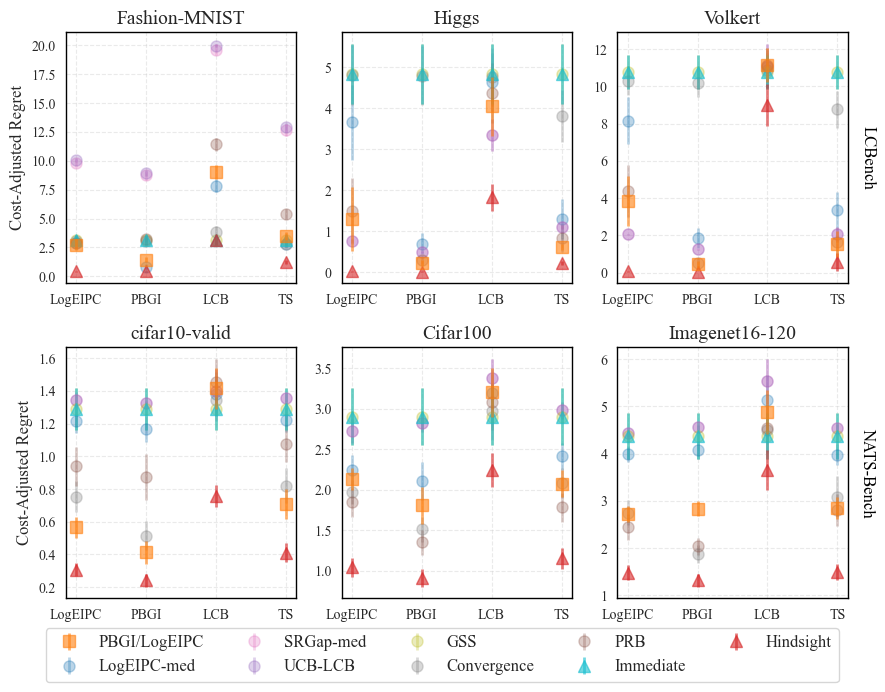

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import ceil

# Set style
sns.set_style('whitegrid', {
    'grid.linestyle': '--',
    'grid.alpha': 0.4
})

plt.style.use('seaborn-v0_8-bright')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    # 'xtick.rotation': 45,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.autolayout': False,  # we'll call tight_layout() explicitly
})


def style_spines(ax, color='black', linewidth=1):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(linewidth)

n_acq_cols = len(acq_order)

n_rows, n_cols = 2, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3.6 * n_rows), sharey=False)
axes_flat = axes.flatten()

for ds_idx, d in enumerate(dataset_names):
    ax = axes_flat[ds_idx]
    best_acc = best_acc_per_dataset[d]
    best_error = 100. - best_acc
    
    # Get dataset-specific lambda value
    lam = dataset_lambda[d]
    lam_str = f"1e-{int(round(-np.log10(lam)))}"

    for j, acq in enumerate(acq_order):
        fixed_acq = f"PBGI({lam_str})" if acq == 'PBGI' else acq

        for rule in stopping_rules:
            if rule['acq_key'] != f"PBGI({lam_str})":
                continue

            stop_vals = []
            non_stopping_count = 0
            num_seeds = len(metrics_per_acq[d][fixed_acq]["estimated cumulative cost"])
            for seed in range(num_seeds):
                errs = metrics_per_acq[d][fixed_acq]["final test error"][seed][:201]
                costs = metrics_per_acq[d][fixed_acq]["estimated cumulative cost"][seed][:201]
                if rule['is_hindsight']:
                    regs = np.array(errs) - best_error + lam * np.array(costs)
                    stop_idx = int(np.argmin(regs))
                else:
                    # Allow early stopping for 'Immediate'
                    start_idx = 0 if rule['stp_key'] == 'Immediate' else init
                    stop_idx = next((i for i in range(start_idx, len(errs))
                                    if rule['condition_fn'](i, seed, d)), len(errs) - 1)
                    if stop_idx == len(errs) - 1:
                        non_stopping_count += 1
                stop_vals.append((errs[stop_idx] - best_error) + lam * costs[stop_idx])

            mean_val = np.mean(stop_vals)
            err_val = np.std(stop_vals) / np.sqrt(len(stop_vals))

            alpha = 0.6 if (rule['stp_key'] == 'PBGI' or rule['is_hindsight'] or rule['stp_key'] == 'Immediate') else 0.3
            zorder = 3 if rule['stp_key'] == 'PBGI' else 2
            marker = rule['marker']
            
            ax.errorbar(j, mean_val, yerr=2 * err_val,
                        fmt=marker, markersize=8, linewidth=2,
                        color=rule['color'], capsize=0,
                        alpha=alpha, zorder=zorder, label=rule['label'])

    ax.set_xticks(range(n_acq_cols))
    ax.set_xticklabels(acq_order)
    ax.set_title("Fashion-MNIST" if d == "Fashion-MNIST"
                 else d if d == "cifar10-valid"
                 else d.capitalize())
    ax.grid(True, linestyle='--', alpha=0.4)
    style_spines(ax)

    # Compute row/col from dataset index
    row = ds_idx // n_cols
    col = ds_idx % n_cols

    # Y label only on the leftmost column of each row
    if col == 0:
        ax.set_ylabel("Cost-Adjusted Regret")

    # Right-side labels for the last column in each row
    if col == n_cols - 1:
        right_label = 'LCBench' if row == 0 else 'NATS-Bench'
        ax.text(1.05, 0.5, right_label, transform=ax.transAxes,
                rotation=-90, va='center', ha='left', fontsize=12, color='black')

# Hide unused subplots (if any)
for k in range(len(dataset_names), len(axes_flat)):
    axes_flat[k].set_visible(False)

# Shared legend
handles, labels = axes_flat[0].get_legend_handles_labels()
legend_hls = dict(zip(labels, handles))
fig.legend(legend_hls.values(), legend_hls.keys(),
           loc='lower center', bbox_to_anchor=(0.5, -0.02),
           ncol=ceil(len(legend_hls) / 2), fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('../plots/BarPlot_LCBench_NATS.pdf', bbox_inches='tight')
plt.show()